<div style="background: linear-gradient(135deg, #000000 0%, #1a1a1a 50%, #06C167 100%); padding: 50px 40px; border-radius: 16px; text-align: center;">

<h1 style="color: white; font-size: 2.8em; font-weight: 900; margin: 0;">🚗 UBER DATA ANALYSIS</h1>
<p style="color: #06C167; font-size: 1.3em; margin: 12px 0 20px 0; font-weight: 600;">Introduction to NumPy · Pandas · Matplotlib · Seaborn</p>
<div style="background: rgba(255,255,255,0.1); border-radius: 8px; padding: 12px 24px; display: inline-block;">
<p style="color: white; font-size: 1.1em; margin: 0;"><em>Case Study: Solving the Uber Ride Cancellation Crisis</em></p>
</div>
<p style="color: #aaa; margin-top: 20px; font-size: 0.95em;">Audience: Beginners &nbsp;|&nbsp; Platform: Google Colab &nbsp;|&nbsp; Duration: 6 Hours</p>
</div>

---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">🚗 MODULE 0 — The Business Problem</h2>
<p style="color: #aaa; margin: 6px 0 0 0;">Set the scene before touching any code</p>
</div>

## The Story

> *You are a Data Scientist at Uber. Your Product Manager walks in on Monday morning and says:*
>
> **"Riders are furious. They book a cab, but either the driver cancels or the app says 'No Cars Available' — especially for airport trips. We are losing thousands of rides every week.**
>
> **Your job: find out WHY and tell us what to do about it."**

---

### 🤔 Think Before You Code

Before opening any data, a good analyst asks clarifying questions first.

| ❓ Question | 🎯 Why it matters |
|------------|------------------|
| Is this happening at specific times of day? | Could be a rush-hour problem |
| Is it City→Airport, Airport→City, or both? | Different routes may need different fixes |
| Is the failure 'Cancelled' or 'No Cars Available'? | These are completely different root causes |
| Has anything changed recently (incentives, app updates)? | Could point to a single trigger |

> 💡 **The data we have can answer all of these. That's exactly what we'll do today.**

---

### 🛠️ Our Toolkit (The Kitchen Analogy)

```
Python (bare)  =  Kitchen with only a stove and sink
NumPy          =  A fast scientific calculator
Pandas         =  An Excel spreadsheet (but 100× more powerful)
Matplotlib     =  Excel's "Insert Chart" button
Seaborn        =  A smarter, prettier chart tool
```


---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">📦 MODULE 1 — Importing Libraries</h2>
<p style="color: #aaa; margin: 6px 0 0 0;">Bringing our tools to the workbench</p>
</div>

## Why do we import?

Python on its own is a bare kitchen. **Libraries** are the pots, knives, and pans. Importing is how we bring them out.

```python
import  numpy  as  np
  ↑               ↑
"bring in"    "call it this for short"
```

Without shortcuts you'd write `numpy.array(...)` every time. With `np` you write `np.array(...)`. Saves thousands of keystrokes!

| Shortcut | Library | What it does |
|----------|---------|-------------|
| `np` | NumPy | Fast maths on large arrays |
| `pd` | Pandas | Tables — load, filter, analyse |
| `plt` | Matplotlib | Draw basic charts |
| `sns` | Seaborn | Draw beautiful statistical charts |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style('whitegrid')

---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">🔢 MODULE 2 — NumPy: The Fast Calculator</h2>
<p style="color: #aaa; margin: 6px 0 0 0;">Process a million numbers in one shot</p>
</div>

## What is NumPy?

**NumPy = Numerical Python.** It is the foundation everything else is built on. Think of it as a calculator that handles a million numbers at once.

### Python List vs NumPy Array

```
Python list — numbers scattered in memory → SLOW
[ box1 ][ box2 ][ box3 ][ box4 ][ box5 ]

NumPy array — numbers packed side by side → FAST (50–300×)
| 1 | 2 | 3 | 4 | 5 |  ← like a ruler
```

### NumPy → Excel mapping

| NumPy | Excel |
|-------|-------|
| `np.mean(arr)` | `=AVERAGE()` |
| `np.max(arr)` | `=MAX()` |
| `np.min(arr)` | `=MIN()` |
| `np.sum(arr)` | `=SUM()` |
| `np.std(arr)` | `=STDEV()` |


In [ ]:
# NUMPY EXAMPLE 1: Ride Duration Statistics
# We have 10 sample ride durations (minutes). Let's analyse them.

ride_durations = np.array([12, 25, 8, 45, 30, 18, 22, 15, 37, 28])
#                np.array( )  ← converts a Python list into a NumPy array

print("Ride durations (min):", ride_durations)
print()
print("Average :", np.mean(ride_durations), "min")
print("Longest :", np.max(ride_durations),  "min")
print("Shortest:", np.min(ride_durations),  "min")
print("Median  :", np.median(ride_durations), "min")
print("Std Dev :", round(np.std(ride_durations), 2), "min")

Ride durations (min): [12 25  8 45 30 18 22 15 37 28]

Average : 24.0 min
Longest : 45 min
Shortest: 8 min
Median  : 23.5 min
Std Dev : 10.88 min


### ⚡ Vectorised Operations — NumPy's Superpower

In Excel you drag a formula down every row. NumPy applies the formula to **all rows at once** — even one million rows.

```
Excel approach  →  drag formula down each row  (slow, tedious)
NumPy approach  →  base_fares * 1.5            (one line, instant)
```


In [ ]:
# NUMPY EXAMPLE 2: Surge Pricing
# Uber charges 1.5× during peak hours.
# Multiply ALL fares at once — no loop needed!

base_fares  = np.array([150, 200, 120, 300, 250])   # fares in Rupees
surge_fares = base_fares * 1.5                       # apply to ALL at once

print("Base fares  (₹):", base_fares)
print("Surge fares (₹):", surge_fares)
print()
print("NumPy multiplied all 5 values in one line.")
print("At 1 million rows it would still be one line — and take milliseconds!")

Base fares  (₹): [150 200 120 300 250]
Surge fares (₹): [225. 300. 180. 450. 375.]

NumPy multiplied all 5 values in one line.
At 1 million rows it would still be one line — and take milliseconds!


In [ ]:
np.array([150, 200, 120, 300, 250])

array([150, 200, 120, 300, 250])

---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">🗂️ MODULE 3 — Pandas: Excel in Python</h2>
<p style="color: #aaa; margin: 6px 0 0 0;">Load, explore, clean, and filter your data</p>
</div>

## What is a DataFrame?

A **DataFrame** is a table — just like an Excel spreadsheet. Rows are rides, columns are details about each ride.

```
   Request id  | Pickup point | Driver id | Status
   ────────────┼──────────────┼───────────┼──────────────────
   619         │ Airport      │ 1         │ Trip Completed   ← row 0
   867         │ Airport      │ 1         │ Trip Completed   ← row 1
   1807        │ City         │ 1         │ Cancelled        ← row 2
   ↑
   index (row number — Pandas adds this automatically)
```


In [ ]:
sample_data = {
    'RideID':   [101, 102, 103, 104, 105],
    'Pickup':   ['Airport', 'City', 'Airport', 'City', 'Airport'],
    'Duration': [35, 22, 48, 15, 60],
    'Status':   ['Completed', 'Cancelled', 'Completed', 'Completed', 'No Cars']
}

sample_df = pd.DataFrame(sample_data)
sample_df

,RideID,Pickup,Duration,Status
0,101,Airport,35,Completed
1,102,City,22,Cancelled
2,103,Airport,48,Completed
3,104,City,15,Completed
4,105,Airport,60,No Cars


In [ ]:
df = pd.read_excel('/content/uber-data.xlsx')
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47


In [ ]:
df.shape

(6745, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   object        
 4   Request timestamp  6745 non-null   datetime64[ns]
 5   Drop timestamp     2831 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 316.3+ KB


In [ ]:
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'])
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   object        
 4   Request timestamp  6745 non-null   datetime64[ns]
 5   Drop timestamp     2831 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 316.3+ KB


In [ ]:
df['RequestHour'] = df['Request timestamp'].dt.hour

In [ ]:
# df.drop(columns='hour', axis=1,inplace=True)
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8


In [ ]:
def assign_timeslot(hour):
    if hour <= 4: return 'Dawn'
    elif hour <= 9: return 'Early Morning'
    elif hour <= 16: return 'Noon'
    elif hour <= 21: return 'Late Evening'
    else:            return 'Night'

In [ ]:
df['Timeslot'] = df['RequestHour'].apply(assign_timeslot)
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour,Timeslot
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11,Noon
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17,Late Evening
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9,Early Morning
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21,Late Evening
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8,Early Morning


In [ ]:
df['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


In [ ]:
df['Cab Availability'] = df['Status'].apply(
    lambda x: 'Available' if x == 'Trip Completed' else 'Not Available'
)

In [ ]:
df['Cab Availability'].value_counts(normalize=True)

,proportion
Cab Availability,
Not Available,0.580282
Available,0.419718


In [ ]:
status_counts = df['Status'].value_counts()

In [ ]:
status_counts.index

Index(['Trip Completed', 'No Cars Available', 'Cancelled'], dtype='object', name='Status')

In [ ]:
status_counts.values

array([2831, 2650, 1264])

In [ ]:
'''
📊 Basic plots
plt.plot() → line plot
plt.scatter() → scatter plot
plt.bar() → bar chart
plt.barh() → horizontal bar
plt.hist() → histogram
plt.pie() → pie chart
plt.boxplot() → box plot
plt.violinplot() → violin plot
plt.stackplot() → stacked area
plt.fill_between() → area fill
plt.imshow() → image display
plt.contour() → contour plot

⚙️ Figure control
plt.figure() → new figure
plt.title()
plt.xlabel() / plt.ylabel()
plt.subplot() / plt.subplots() → multiple plots
plt.legend()
plt.grid()
'''

'\n📊 Basic plots\nplt.plot() → line plot\nplt.scatter() → scatter plot\nplt.bar() → bar chart\nplt.barh() → horizontal bar\nplt.hist() → histogram\nplt.pie() → pie chart\nplt.boxplot() → box plot\nplt.violinplot() → violin plot\nplt.stackplot() → stacked area\nplt.fill_between() → area fill\nplt.imshow() → image display\nplt.contour() → contour plot\n\n⚙️ Figure control\nplt.figure() → new figure\nplt.title()\nplt.xlabel() / plt.ylabel()\nplt.subplot() / plt.subplots() → multiple plots\nplt.legend()\nplt.grid()\n'

<BarContainer object of 3 artists>

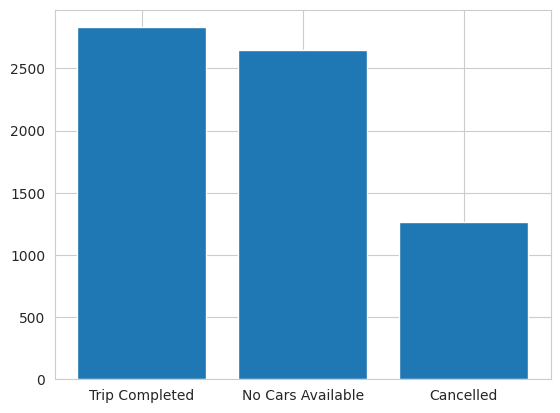

In [ ]:
plt.bar(status_counts.index,status_counts.values)

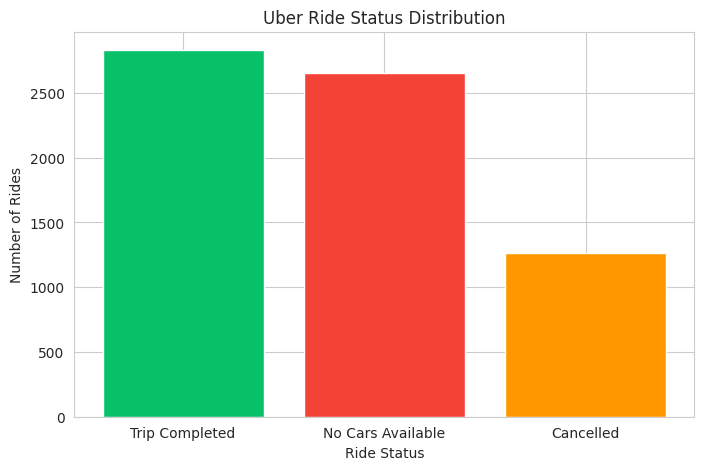

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Uber Ride Status Distribution')
plt.xlabel('Ride Status')
plt.ylabel('Number of Rides')
plt.bar(status_counts.index,status_counts.values,
        color=['#06C167', '#F44336', '#FF9800'])
plt.show()

In [ ]:
pickup_counts = df['Pickup point'].value_counts()
pickup_counts

,count
Pickup point,
City,3507
Airport,3238


In [ ]:
pickup_counts.index

Index(['City', 'Airport'], dtype='object', name='Pickup point')

In [ ]:
pickup_counts.values

array([3507, 3238])

([<matplotlib.patches.Wedge at 0x7caa76f99820>,
 [Text(-0.06886496339721099, 1.0978422549785105, 'City'),
  Text(0.06886492850063763, -1.0978422571674868, 'Airport')])

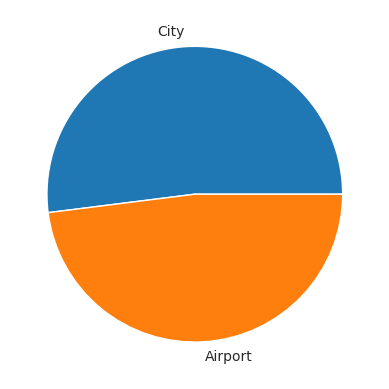

In [ ]:
plt.pie(pickup_counts.values,
        labels=pickup_counts.index)

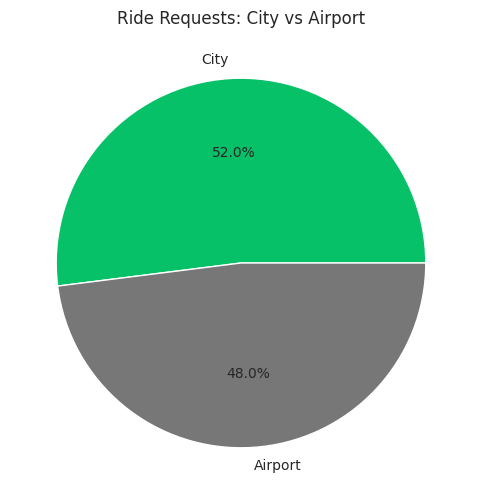

💡 Almost equal split — both routes have problems.


In [ ]:
plt.figure(figsize=(6,6))
plt.title('Ride Requests: City vs Airport')
plt.pie(pickup_counts.values,
        labels = pickup_counts.index,
        autopct='%1.1f%%',
        colors=['#06C167', '#777777']
        )
plt.show()

print("💡 Almost equal split — both routes have problems.")

In [ ]:
hourly_demand = df.groupby('RequestHour').size()
# groupby('RequestHour') groups rows by hour
# .size() counts the rows in each group
hourly_demand

,0
RequestHour,
0,99
1,85
2,99
3,92
4,203
5,445
6,398
7,406
8,423


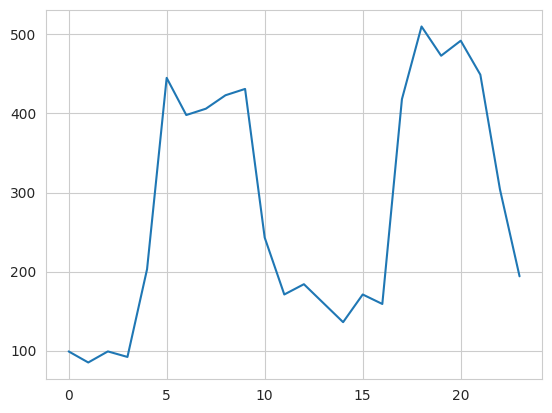

In [ ]:
plt.plot(hourly_demand.index, hourly_demand.values)

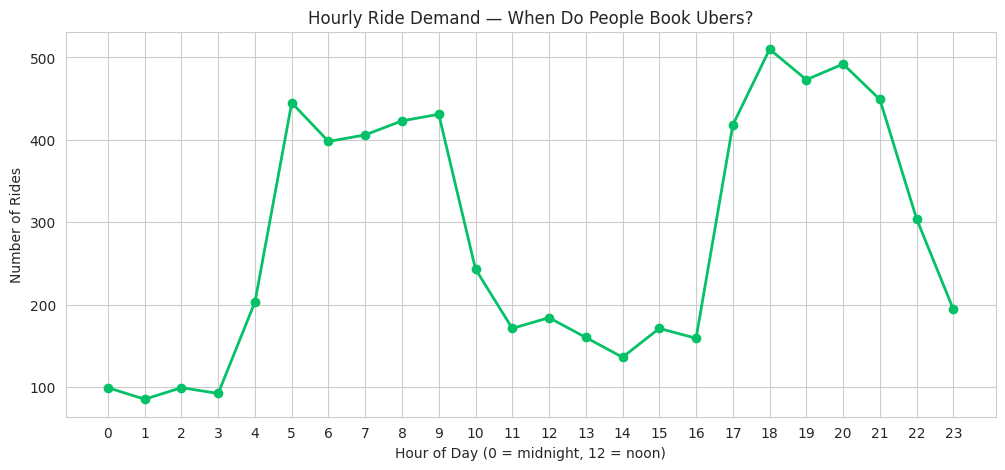

In [ ]:
plt.figure(figsize=(12, 5))
plt.title('Hourly Ride Demand — When Do People Book Ubers?')
plt.xlabel('Hour of Day (0 = midnight, 12 = noon)')
plt.ylabel('Number of Rides')
plt.plot(hourly_demand.index, hourly_demand.values,
         color='#06C167', linewidth=2, marker='o')
plt.xticks(range(0,24))
plt.show()

<Axes: xlabel='Pickup point', ylabel='count'>

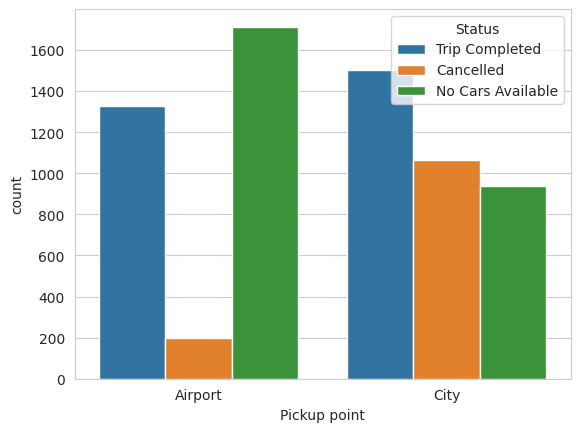

In [ ]:
# sns.countplot(data=df,x='',hue='',palette='')
sns.countplot(data=df,x='Pickup point',hue='Status')

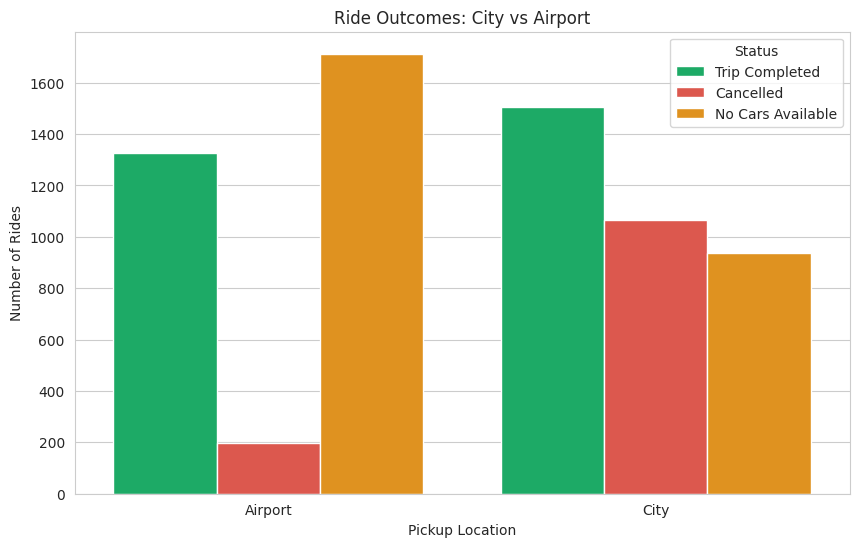

💡 City → HIGH Cancellations | Airport → HIGH No Cars Available
   Two different problems, two different solutions needed!


In [ ]:
plt.figure(figsize=(10,6))
plt.title('Ride Outcomes: City vs Airport')
plt.xlabel('Pickup Location')
plt.ylabel('Number of Rides')
sns.countplot(data=df,x='Pickup point', hue='Status',palette=['#06C167', '#F44336', '#FF9800'])
plt.show()
print("💡 City → HIGH Cancellations | Airport → HIGH No Cars Available")
print("   Two different problems, two different solutions needed!")

In [ ]:
df.groupby(['RequestHour','Status']).size().unstack(fill_value=0)

Status,Cancelled,No Cars Available,Trip Completed
RequestHour,,,
0,3,56,40
1,4,56,25
2,5,57,37
3,2,56,34
4,51,74,78
5,176,84,185
6,145,86,167
7,169,63,174
8,178,90,155


<Axes: xlabel='RequestHour'>

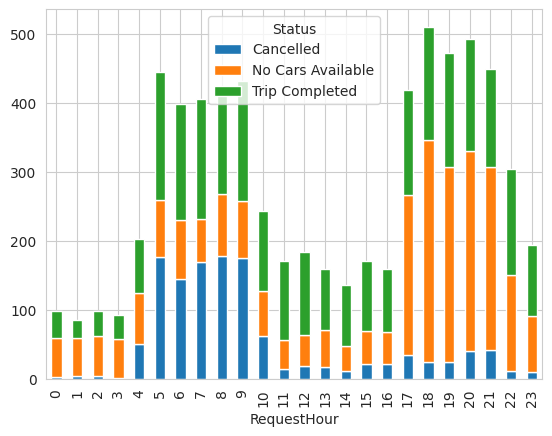

In [ ]:
hourly_status = df.groupby(['RequestHour', 'Status']).size().unstack(fill_value=0)
hourly_status.plot(kind='bar',stacked=True)

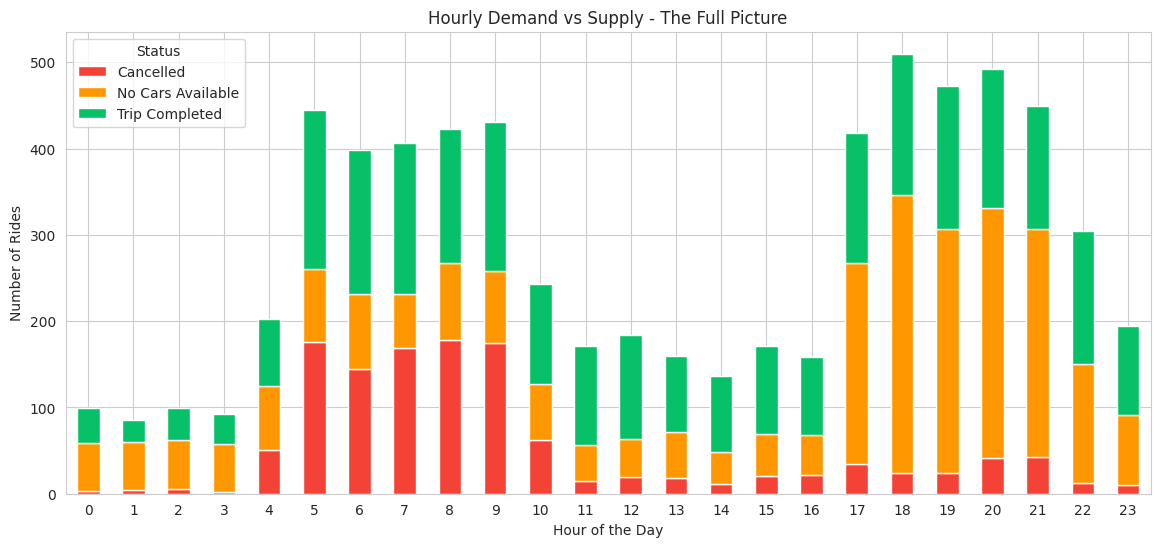

In [ ]:
# sns.countplot(df,x='RequestHour',hue='Status')
hourly_status = df.groupby(['RequestHour','Status']).size().unstack(fill_value=0)
hourly_status.plot(figsize=(14,6),kind='bar',stacked=True,
                   color=['#F44336', '#FF9800', '#06C167'])
plt.title('Hourly Demand vs Supply - The Full Picture')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.show()
'''
जो प्लॉट दिख रहा है, 'Hourly Demand vs Supply - The Full Picture' — उसको देखकर यह साफ़ पता चलता है कि:
सुबह के व्यस्त घंटे (लगभग सुबह 5 बजे से सुबह 9 बजे तक): इस दौरान कैंसल्ड राइड्स (लाल भाग) का हिस्सा काफ़ी बड़ा है।
इसका मतलब है कि लोग राइड्स रिक्वेस्ट तो कर रहे हैं, लेकिन ड्राइवर उन्हें कैंसिल कर रहे हैं।
दिन के मध्य के घंटे (लगभग सुबह 10 बजे से शाम 4 बजे तक): इन घंटों में राइड्स की कुल संख्या कम है,
और 'Trip Completed' (हरा भाग) का अनुपात अन्य स्टेटस के मुकाबले बेहतर है।
शाम के व्यस्त घंटे (लगभग शाम 5 बजे से रात 10 बजे तक): इस दौरान 'No Cars Available'
(नारंगी भाग) की समस्या बहुत ज़्यादा दिख रही है। लोग राइड्स रिक्वेस्ट कर रहे हैं, लेकिन उन्हें गाड़ियाँ नहीं मिल रही हैं।
रात के घंटे (रात 11 बजे से सुबह 4 बजे तक): इस समय राइड्स की संख्या और समस्याएं दोनों कम हैं।
संक्षेप में, सुबह के समय कैंसिलेशन मुख्य समस्या है, जबकि शाम के समय ड्राइवरों की अनुपलब्धता (No Cars Available) एक बड़ी चुनौती है।
'''

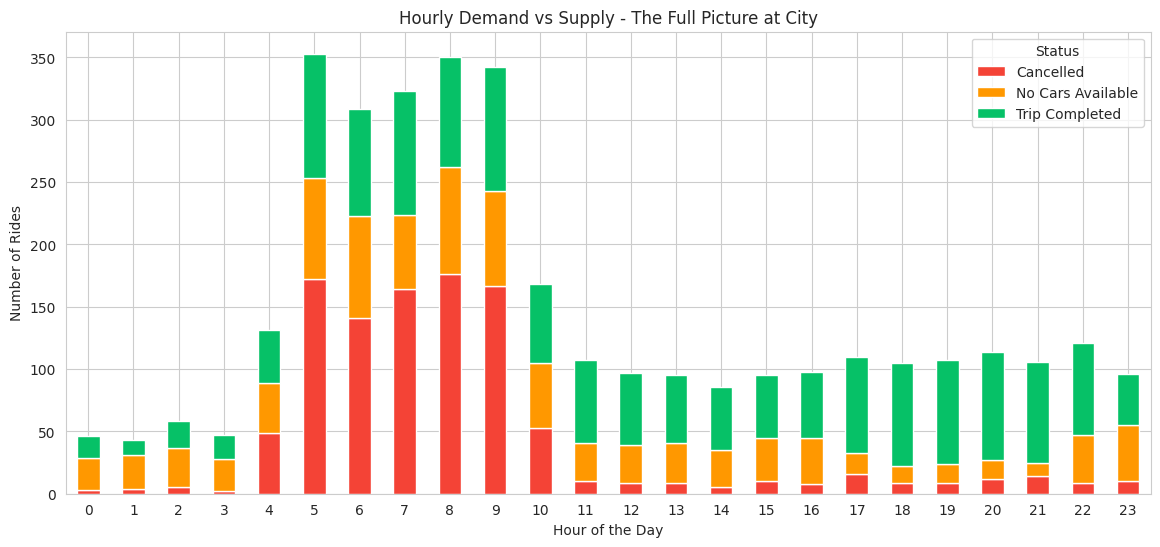

In [ ]:
df_city = df[df['Pickup point']== 'City']
hourly_status = df_city.groupby(['RequestHour','Status']).size().unstack(fill_value=0)
hourly_status.plot(kind='bar',stacked=True,figsize=(14,6),
                   color=['#F44336', '#FF9800', '#06C167'])
plt.title('Hourly Demand vs Supply - The Full Picture at City')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.show()

'''
सुबह के समय (लगभग सुबह 5 बजे से सुबह 9 बजे तक), सिटी पिकअप पॉइंट पर 'Cancelled' राइड्स की संख्या बहुत ज़्यादा है।
इन घंटों में हरे (Trip Completed) और नारंगी (No Cars Available) बार के मुक़ाबले लाल (Cancelled) बार का हिस्सा बहुत बड़ा है।
इसका मतलब है कि सुबह के व्यस्त घंटों में सिटी से राइड बुक करने वाले ग्राहकों की राइड अक्सर ड्राइवर द्वारा कैंसिल कर दी जाती है।
'''

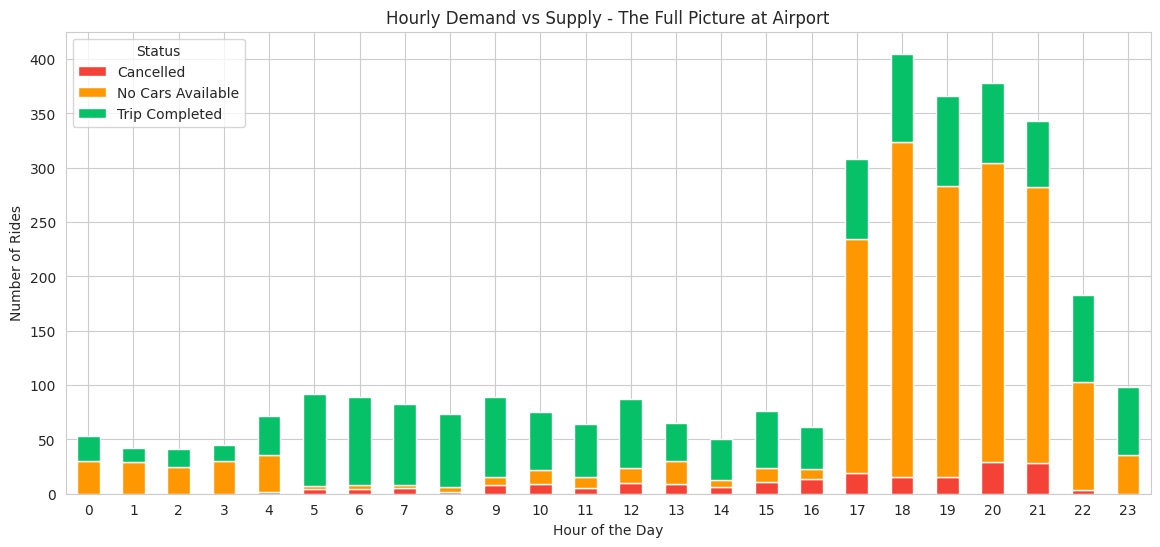

In [ ]:
df_airport = df[df['Pickup point']=='Airport']
hourly_status = df_airport.groupby(['RequestHour','Status']).size().unstack(fill_value=0)
hourly_status.plot(kind='bar',stacked=True,figsize=(14,6),
                   color=['#F44336', '#FF9800', '#06C167'])
plt.title('Hourly Demand vs Supply - The Full Picture at Airport')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.show()

'''
शाम के समय (लगभग शाम 5 बजे से रात 10 बजे तक), एयरपोर्ट पर 'No Cars Available' की समस्या बहुत ज़्यादा है।
इन घंटों में हरे (Trip Completed) और लाल (Cancelled) बार के मुक़ाबले नारंगी ('No Cars Available') बार का हिस्सा बहुत बड़ा है।
इसका मतलब है कि शाम को एयरपोर्ट पर राइड्स की डिमांड तो है, लेकिन ड्राइवर उपलब्ध नहीं हैं, जिसकी वजह से बहुत सारे राइड रिक्वेस्ट 'No Cars Available' में कन्वर्ट हो जाते हैं।
'''

In [ ]:
'''
Okay, the business problem solution, based on the graphs:
Main Issues and Reasons (as seen from the graphs):
Morning hours (5-9 AM): City pickups are experiencing high cancellations.

Reason: It seems drivers are cancelling rides from City to Airport.
Maybe they think they won't get an immediate return ride after an Airport drop, or there's too much traffic.
Evening hours (5-10 PM): 'No Cars Available' is a big problem at the Airport.

Reason: There's a shortage of drivers at the Airport during these hours.
It's possible drivers are ending their shifts and going home, or they fear not getting a ride back to the city from the airport.

Suggested Solutions:
To reduce City to Airport ride cancellations (morning hours):
Give special incentives (like bonus payments or guaranteed return rides) to drivers for taking City to Airport rides during peak morning hours.
To solve 'No Cars Available' at the Airport (evening hours):

Offer special incentives for drivers to stay available at the Airport and take rides from there during peak evening hours.
This could include extra bonuses for Airport pickups or for waiting longer at the Airport.
'''